## Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
try:
    import pyarrow
except:
    ! pip install pyarrow
    import pyarrow

## Helper Classes

In [2]:
def tag_data_set_helper(flt_row_prop):
    if flt_row_prop <= 0.50:
        return 'train'
    elif flt_row_prop <= 0.75:
        return 'valid'
    else:
        return 'test'


class SplitData:
    def __init__(self, str_bucket, str_task_import, str_task, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_task_import = str_task_import
        self.str_task = str_task
        self.str_dirname_output = str_dirname_output

    def import_data(self):
        print('Importing data from S3...')
        str_uri_ratings = f's3://{self.str_bucket}/{self.str_task_import}/ratings.parquet'
        str_uri_users = f's3://{self.str_bucket}/{self.str_task_import}/users.parquet'
        str_uri_movies = f's3://{self.str_bucket}/{self.str_task_import}/movies.parquet'

        df_ratings = pd.read_parquet(str_uri_ratings)
        df_users = pd.read_parquet(str_uri_users)
        df_movies = pd.read_parquet(str_uri_movies)

        # merge
        self.df = df_ratings.merge(
            df_users, on='user_id', how='left',
        ).merge(
            df_movies, on='movie_id', how='left',
        )
        self.df.sort_values(by='timestamp', ascending=True, inplace=True)
        self.df.reset_index(drop=True, inplace=True)
        print(f'  Merged dataset: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns')
        return self

    def tag_data_set(self):
        print('Tagging data set (chronological split)...')
        int_nrows = self.df.shape[0]
        self.df['row'] = range(1, int_nrows + 1)
        self.df['row_prop'] = self.df['row'] / int_nrows
        self.df['data_set'] = self.df['row_prop'].apply(tag_data_set_helper)
        self.df.drop(['row', 'row_prop'], axis=1, inplace=True)
        print(f'  Split complete.')
        return self

    def get_info_by_data_set(self):
        print('Summary by data set:')
        df_tmp = self.df.copy()
        df_tmp['count'] = 1
        df_tmp['min_date'] = df_tmp['timestamp']
        df_tmp['max_date'] = df_tmp['timestamp']

        dict_agg = {
            'count': 'sum',
            'min_date': 'min',
            'max_date': 'max',
            'rating': 'mean',
        }
        df_pivot = df_tmp.groupby(by='data_set', as_index=False).agg(dict_agg)
        df_pivot['prop_row'] = df_pivot['count'] / df_pivot['count'].sum()
        df_pivot['n_users'] = df_tmp.groupby('data_set')['user_id'].nunique().values
        df_pivot['n_movies'] = df_tmp.groupby('data_set')['movie_id'].nunique().values

        # reorder
        list_order = ['train', 'valid', 'test']
        df_pivot['data_set'] = pd.Categorical(df_pivot['data_set'], categories=list_order, ordered=True)
        df_pivot.sort_values('data_set', inplace=True)

        self.df_pivot = df_pivot
        print(df_pivot.to_string(index=False))
        return self

    def plot_split_summary(self):
        df_plot = self.df_pivot.copy()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Out-of-Time Data Split Summary', fontsize=14, y=1.02)

        # mean rating by split
        bars = axes[0].bar(
            df_plot['data_set'].astype(str),
            df_plot['rating'],
            color=['tab:blue', 'tab:orange', 'tab:green'],
        )
        for bar, val in zip(bars, df_plot['rating']):
            axes[0].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}',
                ha='center', va='bottom', fontweight='bold',
            )
        axes[0].set_xlabel('Data Set')
        axes[0].set_ylabel('Mean Rating')
        axes[0].set_title('Mean Rating by Split')

        # count by split
        bars = axes[1].bar(
            df_plot['data_set'].astype(str),
            df_plot['count'],
            color=['tab:blue', 'tab:orange', 'tab:green'],
        )
        for bar, val, prop in zip(bars, df_plot['count'], df_plot['prop_row']):
            axes[1].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + df_plot['count'].max() * 0.01,
                f'{val:,}\n({prop:.1%})',
                ha='center', va='bottom', fontweight='bold',
            )
        axes[1].set_xlabel('Data Set')
        axes[1].set_ylabel('Number of Ratings')
        axes[1].set_title('Rating Count by Split')

        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/split_summary.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def save_df(self):
        str_uri_export = f's3://{self.str_bucket}/{self.str_task}/df.parquet'
        print(f'Saving to {str_uri_export}...')
        self.df.to_parquet(str_uri_export, index=False)
        print('Save complete.')
        return self

## Constants

In [3]:
str_bucket = 'recommender-system-demo'
str_task = '02_split_data'
str_task_import = '00_data_collection'
str_dirname_output = './output'

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Initialize Split Data Class

In [5]:
cls_split = SplitData(
    str_bucket=str_bucket,
    str_task_import=str_task_import,
    str_task=str_task,
    str_dirname_output=str_dirname_output,
)

## Import Data

In [6]:
cls_split.import_data()

Importing data from S3...
  Merged dataset: 1,000,209 rows, 10 columns


## Tag Data Set

In [7]:
cls_split.tag_data_set()

Tagging data set (chronological split)...
  Split complete.


## Summary by Data Set

In [8]:
cls_split.get_info_by_data_set()

Summary by data set:
data_set  count            min_date            max_date   rating  prop_row  n_users  n_movies
   train 500104 2000-04-25 23:05:32 2000-10-31 18:46:46 3.602225  0.500000     3255      3551
   valid 250052 2000-10-31 18:46:46 2000-11-26 06:42:19 3.588058  0.250000     2104      3515
    test 250053 2000-11-26 06:42:19 2003-02-28 17:49:50 3.533751  0.250001     2035      3541


## Split Summary Visualization

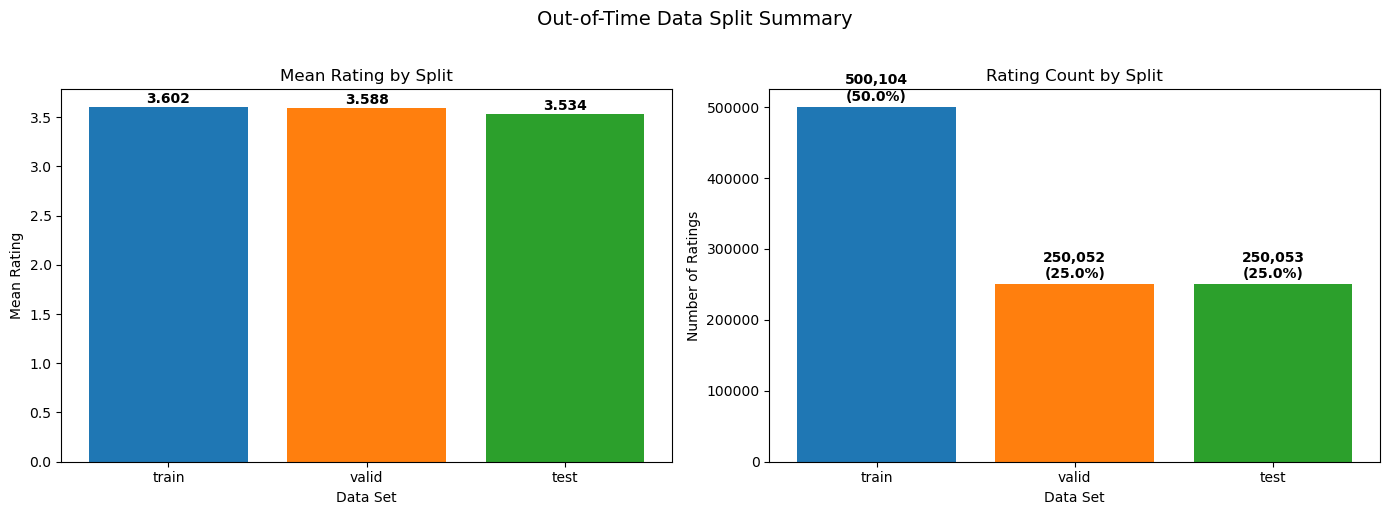

In [9]:
cls_split.plot_split_summary()

## Save to S3

In [10]:
cls_split.save_df()

Saving to s3://recommender-system-demo/02_split_data/df.parquet...
Save complete.
